# Case 4: Analyzing tariff-related acts in the EU Official Journal (2023-2025)

In [1]:
from bulletin.eurlex.api.client import EurlexBulletinClient

# Get the dataset of acts mentioning "tariff" in the title, in English language, between 2023 and 2025.
client = EurlexBulletinClient()

TITLE_CONTAINS = "tariff"
LANGUAGE = "ENG"

# Ask get_acts to extract all metadata directly as a DataFrame.
acts_df = client.get_acts(
    date="2023-01-01",
    date_end="2025-12-31",
    title_contains=TITLE_CONTAINS,
    language=LANGUAGE,
    output_format="df",
)

print(acts_df.head())
print(f"Total acts retrieved: {len(acts_df)}")

                                             act_uri  \
0  https://eur-lex.europa.eu/eli/reg_impl/2023/25...   
1  https://eur-lex.europa.eu/eli/reg_impl/2023/25...   
2  https://eur-lex.europa.eu/eli/reg/2022/2583/co...   
3  https://eur-lex.europa.eu/eli/reg/2022/2583/co...   
4  https://eur-lex.europa.eu/eli/reg_impl/2023/60...   

                                           celex_uri act_number  \
0  http://publications.europa.eu/resource/celex/3...        254   
1  http://publications.europa.eu/resource/celex/3...        254   
2  http://publications.europa.eu/resource/celex/3...       2583   
3  http://publications.europa.eu/resource/celex/3...       2583   
4  http://publications.europa.eu/resource/celex/3...        608   

                                               title        date section_code  \
0  Commission Implementing Regulation (EU) 2023/2...  2023-02-07          NaN   
1  Commission Implementing Regulation (EU) 2023/2...  2023-02-07          NaN   
2  Corrigendum to

Note: you may need to restart the kernel to use updated packages.


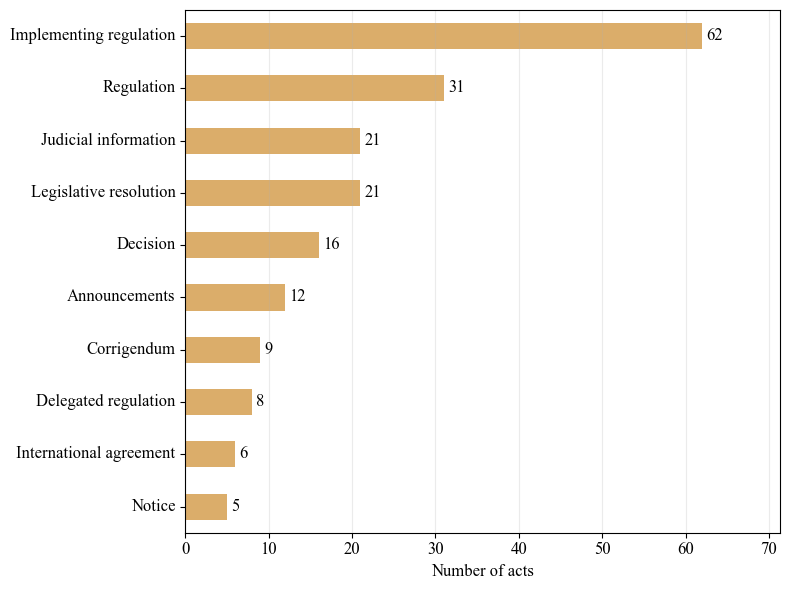

In [2]:
%pip install matplotlib
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "font.size": 10,          # Base font size
    "axes.titlesize": 12,     # Title size
    "axes.labelsize": 12,     # Axis label size
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

# Plot the typology of acts mentioned in the title as horizontal bars.
typology_column = "category_label" if "category_label" in acts_df.columns else "category_type"
typology_counts = acts_df[typology_column].value_counts().sort_values(ascending=True)

ax = typology_counts.plot(kind="barh", figsize=(8, 6), color="#DBAD6A")

ax.set_ylabel("")
ax.set_xlabel("Number of acts")
ax.grid(axis="x", alpha=0.25)
ax.tick_params(axis="both", labelsize=12)
plt.yticks(va="center")
ax.set_xlim(0, typology_counts.max() * 1.15)

for p in ax.patches:
    width = p.get_width()
    ax.annotate(
        f'{int(width)}',
        xy=(width, p.get_y() + p.get_height() / 2),
        xytext=(3, 0),
        textcoords="offset points",
        ha='left',
        va='center',
        fontsize=12,
    )

plt.tight_layout()
plt.savefig("../figures/tariff-acts_categories.pdf", format="pdf", bbox_inches="tight")
plt.show()


Note: you may need to restart the kernel to use updated packages.
     ---------------------------------------- 0.0/33.5 MB ? eta -:--:--
     -- ------------------------------------- 1.8/33.5 MB 12.8 MB/s eta 0:00:03
     --------- ------------------------------ 7.6/33.5 MB 22.5 MB/s eta 0:00:02
     --------------- ----------------------- 13.6/33.5 MB 25.1 MB/s eta 0:00:01
     ----------------------- --------------- 20.2/33.5 MB 27.2 MB/s eta 0:00:01
     -------------------------------- ------ 28.0/33.5 MB 29.2 MB/s eta 0:00:01
     --------------------------------------  33.3/33.5 MB 30.3 MB/s eta 0:00:01
     ---------------------------------------- 33.5/33.5 MB 28.5 MB/s  0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_md')
Fetching content for 191 unique acts...


,celex_uri,top_entities
0,http://publications.europa.eu/resource/celex/3...,"Skyr, Canada, Annexes VIII, Annex IX, Annexes ..."
1,http://publications.europa.eu/resource/celex/3...,"Skyr, Canada, Annexes VIII, Annex IX, Annexes ..."
2,http://publications.europa.eu/resource/celex/3...,
3,http://publications.europa.eu/resource/celex/3...,
4,http://publications.europa.eu/resource/celex/3...,"New Zealand, Cheddar, the United Kingdom’s, Au..."
...,...,...
186,http://publications.europa.eu/resource/celex/3...,the Kingdom of Norway
187,http://publications.europa.eu/resource/celex/3...,the Kingdom of Norway
188,http://publications.europa.eu/resource/celex/6...,"Athens, Loewenthal, the Federal Republic of Ge..."
189,http://publications.europa.eu/resource/celex/3...,"Tebuconazole, Hypromellose, ASTM, Cyclopropylm..."


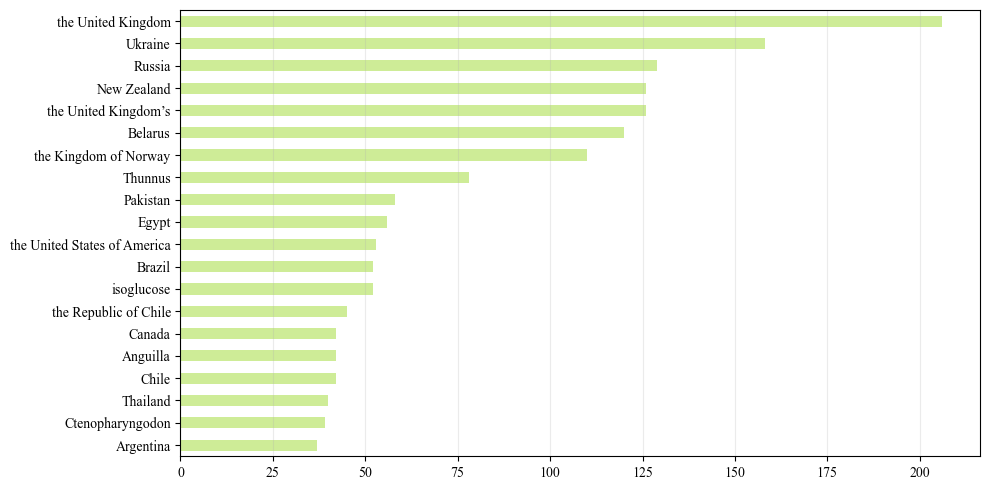

In [3]:
import re
from collections import Counter

import pandas as pd
import spacy

%pip install spacy
!python -m spacy download en_core_web_md
nlp = spacy.load("en_core_web_md")

# Limit the labels to GPE (Geopolitical Entity).
ENTITY_LABELS = {"GPE"}
# Exclude: EU institutions, EU member states, legal terms, pharmaceutical classifications, 
# and common false positives to focus on non-EU geopolitical entities
ENTITY_STOP_TEXTS = {
    # EU Institutions and bodies
    "European Union", "European Commission", "Council of the European Union", 
    "European Parliament", "European Council", "EU", "E.U.", "EC", "ECJ", "CJEU", 
    "European Court", "EFTA", "Strasbourg", "Luxembourg", "Brussels",
    
    # EU Member States (27 countries)
    "France", "Germany", "Italy", "Spain", "Poland", "Netherlands", "Belgium", 
    "Greece", "Portugal", "Austria", "Finland", "Ireland", "Denmark", "Sweden", 
    "Czechia", "Czech Republic", "Hungary", "Romania", "Bulgaria", "Croatia", 
    "Slovenia", "Slovakia", "Lithuania", "Latvia", "Estonia", "Cyprus", "Luxembourg", 
    "Malta",
    
    # Other European countries
    "United Kingdom", "Norway", "Switzerland", "Iceland", "Liechtenstein", 
    "Northern Ireland", "Scotland", "Wales", "England",
    
    # Legal and document terms
    "Regulation", "Directive", "Decision", "Amendment", "Article", "Articles",
    "Section", "Title", "Chapter", "Part", "Clause", "Provision", "Annex",
    "Schedule", "Appendix", "Protocol", "Act", "Whereas",
    
    # Legal archaic/formal terms that fool NER
    "thereon", "thereof", "thereunto", "thereby", "therefrom",
    "hereby", "hereof", "herein", "hereafter", "heretofore",
    "aforesaid", "thence", "whence", "whencesoever", "notwithstanding",
    "nonetheless", "moreover", "furthermore", "however", "whereas",
    
    # Document and administrative terms
    "Member", "Member States", "State", "States", "Authority", "Authorities",
    "Commission", "Council", "Parliament", "Court", "Body", "Bodies",
    "Office", "Agency", "Organization", "Department",
    
    "INN", "Active Pharmaceutical Ingredient", "API", "Substance",
    "Trade", "Trader", "Exporter", "Importer", "Partner", "Partners",
    "Supplier", "Supplier", "Beneficiary", "Applicant", "Operator",
    
    # Common words Spacy misclassifies
    "Regulation", "Amendment", "Procedure", "Process", "Agreement",
    "Treaty", "Convention", "Protocol", "Arrangement", "Subheading"
}

def html_to_text(content_html):
    """Cleans HTML and extracts clean text for analysis."""
    text = re.sub(r"<script.*?</script>|<style.*?</style>", " ", content_html, flags=re.I | re.S)
    text = re.sub(r"<!--.*?-->", " ", text, flags=re.S)
    text = re.sub(r"<[^>]+>", " ", text)
    text = text.replace("&nbsp;", " ").replace("&quot;", '"').replace("&apos;", "'")
    text = text.replace("&lt;", "<").replace("&gt;", ">").replace("&amp;", "&")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def is_valid_entity(entity_text):
    """Validates if a text is a valid geopolitical entity."""
    text = entity_text.strip()
    
    words = text.split()
    if len(words) == 0:
        return False
    
    if len(words) > 1:
        has_long_word = any(len(w) >= 3 for w in words if re.match(r"^[a-zA-Z]", w))
        if not has_long_word:
            return False
    
    if not re.search(r"[a-zA-Z]", text):
        return False
    
    return True

def plot_top(counter, name, color):
    if not counter:
        print(f"No data to plot for: {name}")
        return
    labels, values = zip(*counter.most_common(20))
    ax = pd.Series(values[::-1], index=labels[::-1]).plot(kind="barh", figsize=(10, 5), color=color)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.savefig(f"../figures/{name}.pdf", format="pdf", bbox_inches="tight")
    plt.show()

print(f"Fetching content for {len(acts_df)} unique acts...")
rows, global_entities = [], Counter()

for _, act in acts_df.iterrows():
    try:
        html = client.get_act_content(act["celex_uri"], language=LANGUAGE)
        text = html_to_text(html)
        # Limitar a caracteres que el modelo puede procesar
        doc = nlp(text[: nlp.max_length])
    except Exception as exc:
        print(f"Warning: could not analyze {act['celex_uri']}: {exc}")
        continue

    entities = [
        re.sub(r"\s+", " ", ent.text).strip() 
        for ent in doc.ents
        if (ent.label_ in ENTITY_LABELS
            and ent.text.strip() not in ENTITY_STOP_TEXTS
            and len(ent.text.strip()) > 2
            and is_valid_entity(ent.text))
    ]

    entity_counts = Counter(entities)
    global_entities.update(entity_counts)
    rows.append({
        "celex_uri": act["celex_uri"],
        "top_entities": ", ".join(entity for entity, _ in entity_counts.most_common(6)),
    })

analysis_df = pd.DataFrame(rows)
display(analysis_df)
plot_top(global_entities, f"most_frequent_geopolitical_entities", "#CEEC97")